In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_moons

In [11]:
X, y = make_moons(n_samples=500, noise=0.2, random_state=42)

X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32).view(-1,1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
#bài 4
class ANN(nn.Module):
    
    def __init__(self):
        super(ANN, self).__init__()
        self.layer1 = nn.Linear(2,4)
        self.relu = nn.ReLU()
        self.layer2 = nn.Linear(4,1)
        self.sigmoid = nn.Sigmoid()

    def forward(self,x):
        x = self.relu(self.layer1(x))
        x = self.sigmoid(self.layer2(x))
        return x


model = ANN()

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

losses = []

for epoch in range(100):

    outputs = model(X_train)
    loss = criterion(outputs,y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

print("Final Loss (4 nodes):", loss.item())

Final Loss (4 nodes): 0.30992770195007324


In [13]:
model.eval()

with torch.no_grad():
    
    y_pred = model(X_test)
    y_pred = (y_pred > 0.5).float()
    
    accuracy = (y_pred.eq(y_test).sum() / y_test.size(0)).item()

print("Accuracy:", accuracy)

Accuracy: 0.8700000047683716


In [14]:
class ANN8(nn.Module):

    def __init__(self):
        super(ANN8,self).__init__()

        self.layer1 = nn.Linear(2,8)
        self.relu = nn.ReLU()
        self.layer2 = nn.Linear(8,1)
        self.sigmoid = nn.Sigmoid()

    def forward(self,x):

        x = self.relu(self.layer1(x))
        x = self.sigmoid(self.layer2(x))

        return x


model8 = ANN8()

criterion = nn.BCELoss()
optimizer = optim.Adam(model8.parameters(), lr=0.01)

losses8 = []

for epoch in range(100):

    outputs = model8(X_train)
    loss = criterion(outputs,y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses8.append(loss.item())

print("Final Loss (8 nodes):",loss.item())

Final Loss (8 nodes): 0.2780986726284027


In [15]:
class ANN86(nn.Module):

    def __init__(self):
        super(ANN86,self).__init__()

        self.layer1 = nn.Linear(2,8)
        self.layer2 = nn.Linear(8,6)
        self.relu = nn.ReLU()
        self.output = nn.Linear(6,1)
        self.sigmoid = nn.Sigmoid()

    def forward(self,x):

        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.sigmoid(self.output(x))

        return x


model86 = ANN86()

criterion = nn.BCELoss()
optimizer = optim.Adam(model86.parameters(), lr=0.01)

losses86 = []

for epoch in range(100):

    outputs = model86(X_train)
    loss = criterion(outputs,y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses86.append(loss.item())

print("Final Loss (8+6 nodes):",loss.item())

Final Loss (8+6 nodes): 0.212056502699852


In [16]:
#bài 2
class ANN_logits(nn.Module):

    def __init__(self):
        super(ANN_logits,self).__init__()

        self.layer1 = nn.Linear(2,4)
        self.relu = nn.ReLU()
        self.layer2 = nn.Linear(4,1)

    def forward(self,x):

        x = self.relu(self.layer1(x))
        x = self.layer2(x)

        return x


model_logits = ANN_logits()

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model_logits.parameters(), lr=0.01)

losses_logits = []

for epoch in range(100):

    outputs = model_logits(X_train)
    loss = criterion(outputs,y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses_logits.append(loss.item())

print("Final Loss:",loss.item())

Final Loss: 0.29211151599884033


In [17]:
model_sgd = ANN()

criterion = nn.BCELoss()
optimizer = optim.SGD(model_sgd.parameters(), lr=0.01)

losses_sgd = []

for epoch in range(100):

    outputs = model_sgd(X_train)
    loss = criterion(outputs,y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses_sgd.append(loss.item())

print("Final Loss:",loss.item())

Final Loss: 0.6737434267997742


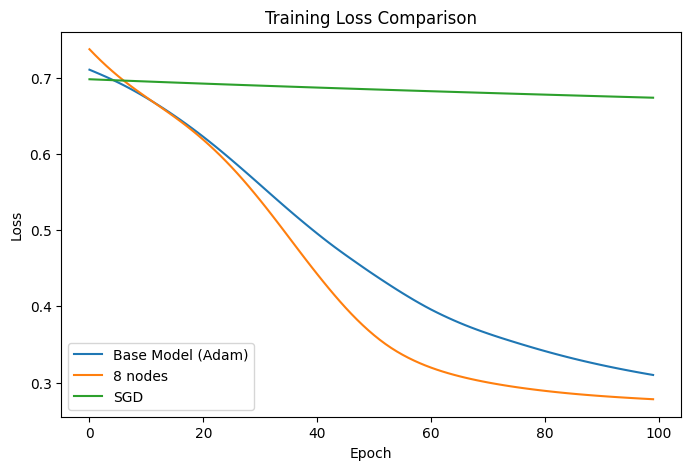

In [18]:
#bài 3
plt.figure(figsize=(8,5))

plt.plot(losses,label="Base Model (Adam)")
plt.plot(losses8,label="8 nodes")
plt.plot(losses_sgd,label="SGD")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")

plt.legend()

plt.show()